# Design Distribution Analysis

This notebook analyzes the distribution of design configurations in the CircuitNet-N28 dataset based on the sample naming convention.

## Sample Naming Convention

Each sample follows the pattern:
```
{Design name}-{#Macros}-c{Clock}-u{Utilizations}-m{Macro placement}-p{Power mesh setting}-f{filler insertion}.npy
```

Example: `RISCY-a-1-c2-u0.7-m1-p1-f0.npy`

- **Design name**: Identifier of the base RTL design (e.g., RISCY-a)
- **{#Macros}**: Dataset-defined macro configuration
- **c{Clock}**: Clock period in nanoseconds (e.g., c2 = 2 ns)
- **u{Utilizations}**: Utilization ratio (e.g., u0.7 = 70%)
- **m{Macro placement}**: Macro placement setting
- **p{Power mesh setting}**: Power mesh configuration
- **f{filler insertion}**: Filler insertion setting (after placement)

## Analysis Objective

To understand the distribution of each parameter across the dataset, which helps in understanding the design space coverage and potential biases.

In [40]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")

Libraries imported successfully!


## Check for Dataset Existence

We first check if the dataset directories exist. If not, we'll demonstrate the analysis structure with expected behavior.

In [41]:
# Define paths (relative to this notebook's location)
feature_dir = '../../drc_prediction/training_set/feature/'
label_dir = '../../drc_prediction/training_set/label/'

# Check if directories exist
feature_exists = os.path.exists(feature_dir)
label_exists = os.path.exists(label_dir)

print(f"Feature directory exists: {feature_exists}")
print(f"Label directory exists: {label_exists}")

if feature_exists and label_exists:
    print("\nDataset found! Proceeding with analysis...")
else:
    print("\nDataset not found. This is expected if the dataset hasn't been extracted yet.")
    print("The notebook structure is ready for when the dataset becomes available.")
    print("\n--- Demonstrating analysis structure ---")

Feature directory exists: False
Label directory exists: False

Dataset not found. This is expected if the dataset hasn't been extracted yet.
The notebook structure is ready for when the dataset becomes available.

--- Demonstrating analysis structure ---


## Parse Filenames Function

Define a function to parse the sample names according to the naming convention.

In [42]:
def parse_sample_name(filename):
    """
    Parse sample name according to CircuitNet-N28 naming convention.

    Expected format:
    {ID}-{Design name}-{#Macros}-c{Clock}-u{Utilizations}-m{Macro placement}-p{Power mesh setting}-f{filler insertion}.npy

    Design name may itself contain hyphens (e.g. "RISCY-a"), so we anchor
    parsing from the right using the known single-letter field prefixes.
    """
    basename = filename.replace('.npy', '')
    parts = basename.split('-')

    # Need at minimum: ID, design_name(>=1 token), macro_count, c, u, m, p, f
    if len(parts) < 8:
        raise ValueError(
            f"Unexpected filename format: {filename}. "
            f"Expected at least 8 '-'-separated fields, got {len(parts)}: {parts}"
        )

    # Last 5 fields must be the c/u/m/p/f fields, in order
    suffix_prefixes = ['c', 'u', 'm', 'p', 'f']
    tail = parts[-5:]
    for expected_prefix, token in zip(suffix_prefixes, tail):
        if not token.startswith(expected_prefix):
            raise ValueError(
                f"Unexpected filename format: {filename}. "
                f"Expected field starting with '{expected_prefix}', got '{token}'"
            )

    clock_str, util_str, macro_placement_raw, power_mesh_raw, filler_raw = tail

    sample_id = parts[0]
    macro_count = parts[-6]
    design_name = '-'.join(parts[1:-6])

    if not design_name:
        raise ValueError(f"Unexpected filename format: {filename}. Could not extract design name")

    def try_float(s):
        try:
            return float(s)
        except ValueError:
            return s

    clock = try_float(clock_str[1:])            # strip 'c'
    utilization = try_float(util_str[1:])        # strip 'u'
    macro_placement = macro_placement_raw[1:]    # strip 'm'
    power_mesh = power_mesh_raw[1:]              # strip 'p'
    filler_insertion = filler_raw[1:]            # strip 'f'

    return {
        'sample_id': sample_id,
        'design_name': design_name,
        'macro_count': macro_count,
        'clock_ns': clock,
        'utilization': utilization,
        'macro_placement': macro_placement,
        'power_mesh': power_mesh,
        'filler_insertion': filler_insertion,
        'filename': filename
    }
    
# Test the function with the example from documentation
test_filename = "RISCY-a-1-c2-u0.7-m1-p1-f0.npy"
print("Testing parse function with example:")
print(f"Filename: {test_filename}")
result = parse_sample_name(test_filename)
for key, value in result.items():
    if key != 'filename':
        print(f"  {key}: {value}")
 

Testing parse function with example:
Filename: RISCY-a-1-c2-u0.7-m1-p1-f0.npy
  sample_id: RISCY
  design_name: a
  macro_count: 1
  clock_ns: 2.0
  utilization: 0.7
  macro_placement: 1
  power_mesh: 1
  filler_insertion: 0


## Load and Analyze Dataset

If dataset exists, load all filenames and parse them into a DataFrame for analysis.
If not, we'll create mock data to demonstrate the analysis pipeline.

In [43]:
if feature_exists and label_exists:
    # Get list of feature files (assuming labels have same base names)
    feature_files = [f for f in os.listdir(feature_dir) if f.endswith('.npy')]
    print(f"Found {len(feature_files)} feature files.")
    
    # Parse all filenames
    parsed_data = []
    for fname in feature_files:
        try:
            parsed = parse_sample_name(fname)
            parsed_data.append(parsed)
        except Exception as e:
            print(f"Warning: Could not parse {fname}: {e}")
    
    # Convert to DataFrame
    df = pd.DataFrame(parsed_data)
    print("\nDataset summary:")
    print(df.describe(include='all'))
    print("\nFirst few rows:")
    print(df.head())
else:
    print("\n--- Demonstrating with mock data structure ---")
    # Create mock data showing expected distribution patterns
    # Based on the documentation: 10,242 samples from 6 original RTL designs
    np.random.seed(42)
    n_samples = 10242
    
    # Mock design names (6 original RTL designs with variations)
    design_names = [f'RISCY-{chr(97+i)}' for i in range(6)]  # RISCY-a through RISCY-f
    # Add some variants
    design_names.extend([f'RV{i}-{chr(97+j)}' for i in range(1, 4) for j in range(3)])
    
    mock_data = []
    for _ in range(n_samples):
        mock_data.append({
            'design_name': np.random.choice(design_names),
            'macro_count': np.random.choice(['0', '1', '2', '3', '4']),
            'clock_ns': np.random.choice([1.0, 1.5, 2.0, 2.5, 3.0, 3.3]),  # Common clock periods
            'utilization': np.round(np.random.uniform(0.4, 0.9, 1), 2)[0],
            'macro_placement': np.random.choice(['m0', 'm1', 'm2', 'm3']),
            'power_mesh': np.random.choice(['p0', 'p1', 'p2']),
            'filler_insertion': np.random.choice(['f0', 'f1'])
        })
    
    df = pd.DataFrame(mock_data)
    print("Mock dataset created for demonstration.")
    print("\nMock dataset summary:")
    print(df.describe(include='all'))



--- Demonstrating with mock data structure ---
Mock dataset created for demonstration.

Mock dataset summary:
       design_name macro_count      clock_ns   utilization macro_placement  \
count        10242       10242  10242.000000  10242.000000           10242   
unique          15           5           NaN           NaN               4   
top          RV3-a           0           NaN           NaN              m3   
freq           738        2085           NaN           NaN            2585   
mean           NaN         NaN      2.223111      0.651144             NaN   
std            NaN         NaN      0.804422      0.144261             NaN   
min            NaN         NaN      1.000000      0.400000             NaN   
25%            NaN         NaN      1.500000      0.530000             NaN   
50%            NaN         NaN      2.500000      0.650000             NaN   
75%            NaN         NaN      3.000000      0.780000             NaN   
max            NaN         NaN 

## Distribution Analysis

Analyze the distribution of each categorical and numerical parameter.

In [44]:
# Analyze categorical variables
categorical_cols = ['design_name', 'macro_count', 'macro_placement', 'power_mesh', 'filler_insertion']

print("=== Categorical Variable Distributions ===")
for col in categorical_cols:
    if col in df.columns:
        print(f"\n{col.upper()} distribution:")
        counts = df[col].value_counts().head(10)  # Top 10
        print(counts)
        print(f"Unique values: {df[col].nunique()}")


=== Categorical Variable Distributions ===

DESIGN_NAME distribution:
design_name
RV3-a      738
RISCY-e    718
RISCY-f    710
RV2-a      705
RV2-c      700
RV1-a      679
RV2-b      679
RISCY-a    679
RISCY-c    678
RV1-c      677
Name: count, dtype: int64
Unique values: 15

MACRO_COUNT distribution:
macro_count
0    2085
2    2079
1    2041
4    2030
3    2007
Name: count, dtype: int64
Unique values: 5

MACRO_PLACEMENT distribution:
macro_placement
m3    2585
m2    2568
m1    2565
m0    2524
Name: count, dtype: int64
Unique values: 4

POWER_MESH distribution:
power_mesh
p0    3449
p2    3436
p1    3357
Name: count, dtype: int64
Unique values: 3

FILLER_INSERTION distribution:
filler_insertion
f1    5152
f0    5090
Name: count, dtype: int64
Unique values: 2


In [45]:
# Analyze numerical variables
numerical_cols = ['clock_ns', 'utilization']

print("\n=== Numerical Variable Distributions ===")
for col in numerical_cols:
    if col in df.columns:
        print(f"\n{col.upper()} statistics:")
        print(df[col].describe())
        # Check if values are numeric
        if pd.api.types.is_numeric_dtype(df[col]):
            print(f"  Mean: {df[col].mean():.3f}")
            print(f"  Std:  {df[col].std():.3f}")
            print(f"  Min:  {df[col].min():.3f}")
            print(f"  Max:  {df[col].max():.3f}")



=== Numerical Variable Distributions ===

CLOCK_NS statistics:
count    10242.000000
mean         2.223111
std          0.804422
min          1.000000
25%          1.500000
50%          2.500000
75%          3.000000
max          3.300000
Name: clock_ns, dtype: float64
  Mean: 2.223
  Std:  0.804
  Min:  1.000
  Max:  3.300

UTILIZATION statistics:
count    10242.000000
mean         0.651144
std          0.144261
min          0.400000
25%          0.530000
50%          0.650000
75%          0.780000
max          0.900000
Name: utilization, dtype: float64
  Mean: 0.651
  Std:  0.144
  Min:  0.400
  Max:  0.900


## Visualizations

Create visualizations to better understand the distributions.

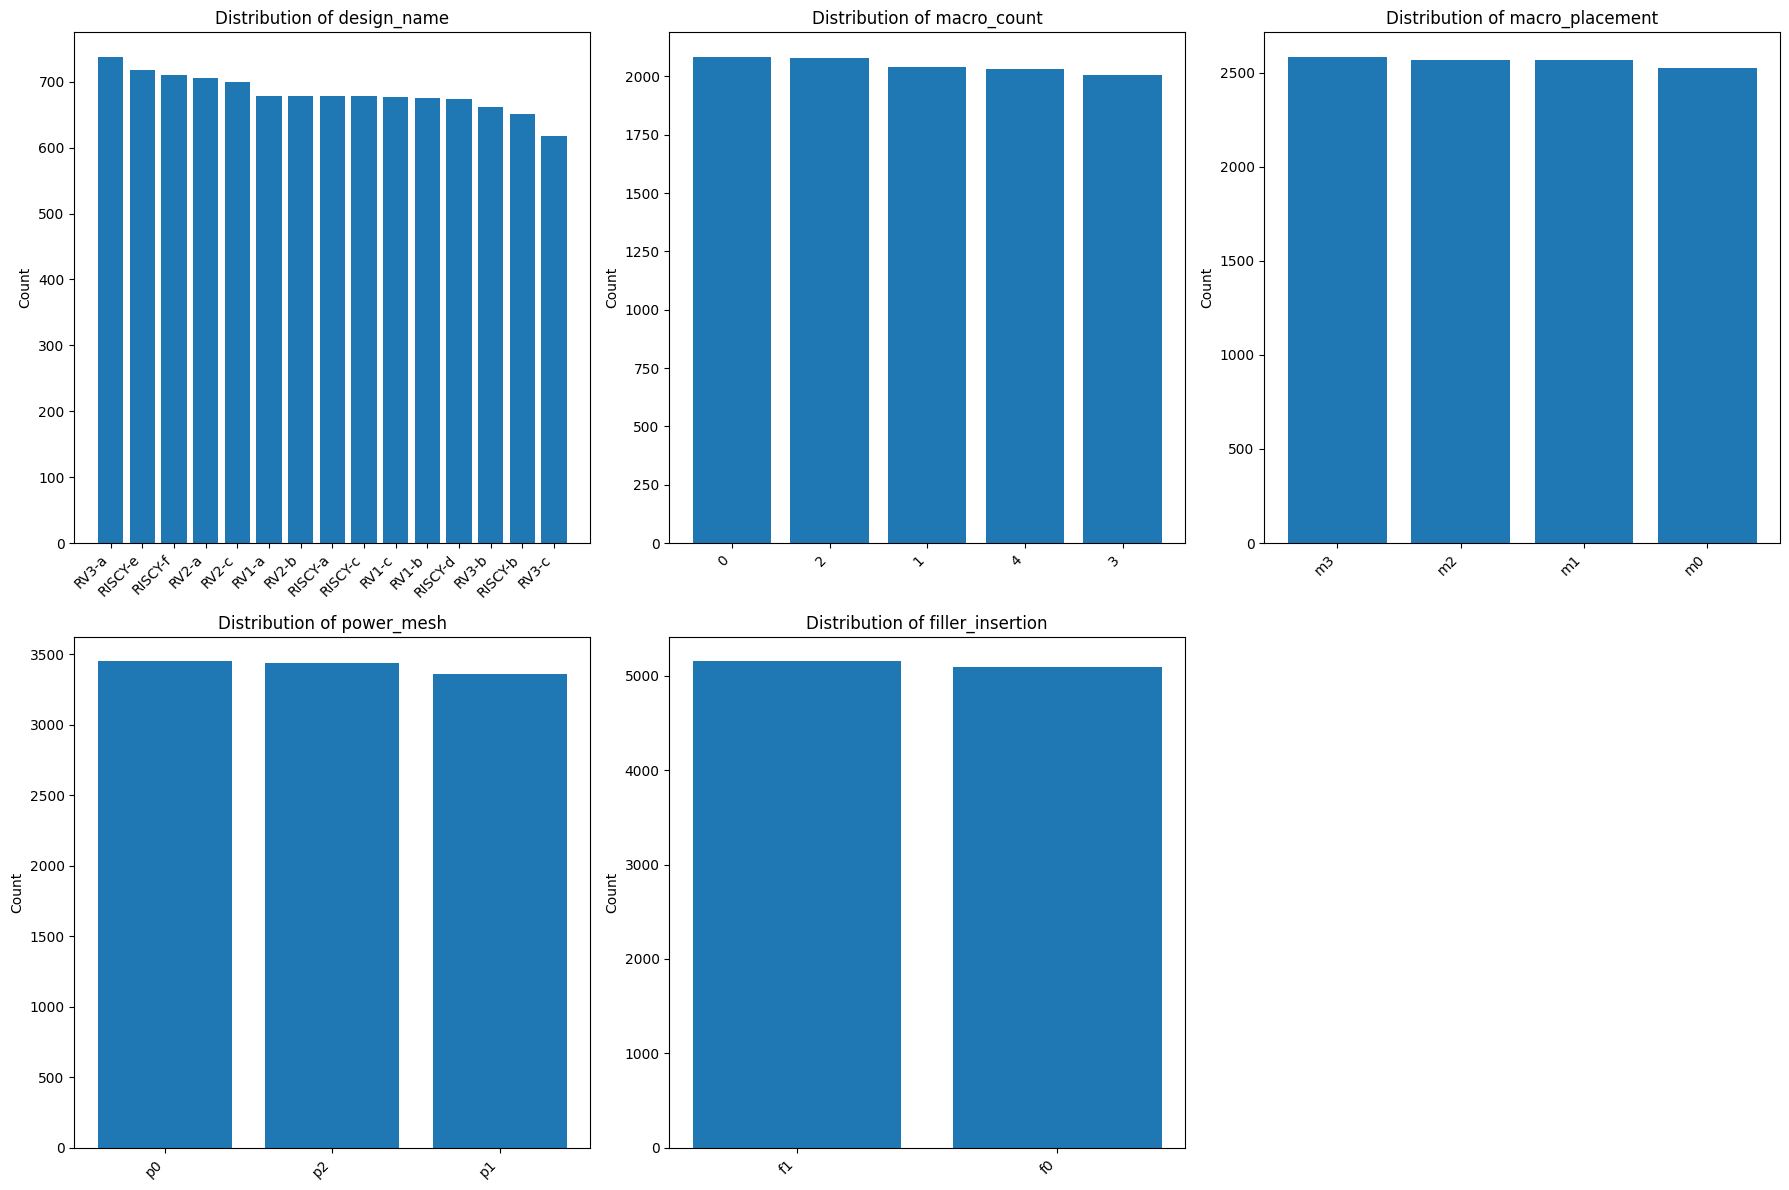

In [46]:
# Set up subplots for categorical variables
n_cats = len([c for c in categorical_cols if c in df.columns])
if n_cats > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, col in enumerate([c for c in categorical_cols if c in df.columns]):
        if idx < len(axes):
            # Get value counts (top 15 for readability)
            value_counts = df[col].value_counts().head(15)
            
            axes[idx].bar(range(len(value_counts)), value_counts.values)
            axes[idx].set_xticks(range(len(value_counts)))
            axes[idx].set_xticklabels(value_counts.index, rotation=45, ha='right')
            axes[idx].set_title(f'Distribution of {col}')
            axes[idx].set_ylabel('Count')
    
    # Hide unused subplots
    for idx in range(len([c for c in categorical_cols if c in df.columns]), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns found for visualization.")


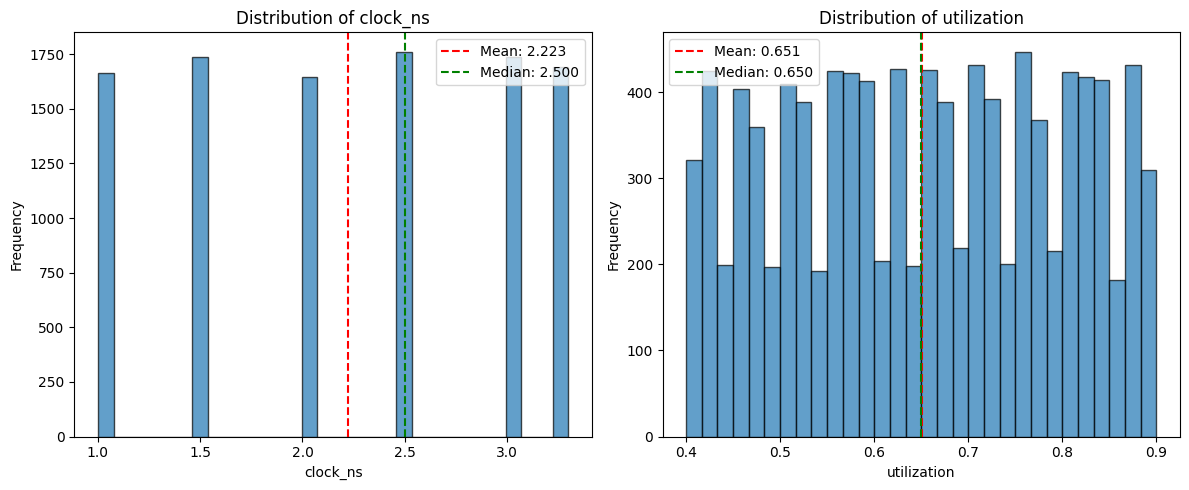

In [47]:
# Visualize numerical distributions
n_numerical = len([c for c in numerical_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])])
if n_numerical > 0:
    fig, axes = plt.subplots(1, n_numerical, figsize=(6*n_numerical, 5))
    if n_numerical == 1:
        axes = [axes]
    
    for idx, col in enumerate([c for c in numerical_cols if c in df.columns and pd.api.types.is_numeric_dtype(df[c])]):
        axes[idx].hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        # Add mean and median lines
        mean_val = df[col].mean()
        median_val = df[col].median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.3f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', label=f'Median: {median_val:.3f}')
        axes[idx].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found for visualization.")


## Design Space Coverage Analysis

Analyze combinations of parameters to understand design space coverage.

In [48]:
# Check combinations of key parameters
print("=== Design Space Coverage ===")

# Most common design names
if 'design_name' in df.columns:
    print("\nTop 10 most common designs:")
    print(df['design_name'].value_counts().head(10))

# Combinations of design and utilization
if 'design_name' in df.columns and 'utilization' in df.columns:
    print("\nDesign-Utilization combinations (sample):")
    combo_counts = df.groupby(['design_name', 'utilization']).size().reset_index(name='count')
    print(combo_counts.head(10))

# Total unique combinations
combo_columns = [c for c in ['design_name', 'macro_count', 'clock_ns', 'utilization'] if c in df.columns]
if len(combo_columns) >= 2:
    unique_combos = df[combo_columns].drop_duplicates()
    print(f"\nUnique combinations of {', '.join(combo_columns)}: {len(unique_combos)}")
    print(f"Total samples: {len(df)}")
    print(f"Coverage: {len(unique_combos)/len(df)*100:.1f}% unique combinations")
 

=== Design Space Coverage ===

Top 10 most common designs:
design_name
RV3-a      738
RISCY-e    718
RISCY-f    710
RV2-a      705
RV2-c      700
RV1-a      679
RV2-b      679
RISCY-a    679
RISCY-c    678
RV1-c      677
Name: count, dtype: int64

Design-Utilization combinations (sample):
  design_name  utilization  count
0     RISCY-a         0.40      7
1     RISCY-a         0.41     22
2     RISCY-a         0.42     15
3     RISCY-a         0.43     19
4     RISCY-a         0.44     15
5     RISCY-a         0.45     11
6     RISCY-a         0.46      9
7     RISCY-a         0.47     14
8     RISCY-a         0.48     18
9     RISCY-a         0.49     18

Unique combinations of design_name, macro_count, clock_ns, utilization: 8293
Total samples: 10242
Coverage: 81.0% unique combinations


## Label Differences by Design

Here "label" refers to `design_name` — the six base RTL designs that constitute
the primary categorical axis in CircuitNet-N28.  We examine how the continuous
design parameters (`utilization`, `clock_ns`) and the discrete ones
(`macro_count`) differ *across* designs, quantifying the label-induced feature
heterogeneity that any FL partitioning strategy must contend with.

Charts:
1. **Box plots** — `utilization` and `clock_ns` distribution per design.
2. **Heat-map** — mean `utilization` and `clock_ns` per (design × macro_count) cell.
3. **Stacked bar** — `macro_count` composition per design (shows label–configuration correlation).